# Migas-1.5: Counterfactual Scenarios

Most time-series models only see numbers. Migas-1.5 fuses **text and time series**,
so you can rewrite the narrative and watch the forecast respond. This notebook
demonstrates **counterfactual scenario analysis** on live crude-oil data: we fetch
recent prices, create a factual summary, then swap the forward-looking outlook for
bullish or bearish alternatives and watch the forecast diverge.

**What you will see:** the same price history produces three dramatically different
forecasts depending on the text — confirming that Migas-1.5 genuinely integrates
textual signals into its predictions.

**Requirements:** `uv sync` from the repo root. An `ANTHROPIC_API_KEY` 
enables Claude-powered summary generation with web search; without it the notebook
uses a pre-written fallback summary.

**See also:** [Inference Quick Start](migas-1.5-inference-quickstart.ipynb) ·
[Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)

In [1]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

import os
from datetime import datetime, timedelta
from pathlib import Path
from textwrap import dedent

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yfinance as yf
from dotenv import load_dotenv
from IPython import get_ipython
from IPython.display import HTML, display

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

from migaseval import MigasPipeline
from migaseval.counterfactual_utils import (
    display_text_comparison,
    extract_factual,
    linear_slope,
    splice_summary,
)
from migaseval.plotting_utils import COLORS, _draw_forecast_region, apply_migas_style, format_date_axis
from migaseval.summary_utils import generate_summary


apply_migas_style()

## Configuration

Edit the cell below to customize the asset, context length, or LLM settings.
The notebook works with any Yahoo Finance ticker — just change `TICKER` and
`SERIES_NAME`.

In [2]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────────
TICKER      = "USO"                            # <-- CHANGE ME: any Yahoo Finance ticker
SERIES_NAME = "United States Oil Fund (USO)"   # <-- CHANGE ME: human-readable name
CONTEXT_LEN = 64                               # trading days of history
PRED_LEN    = 16                               # forecast horizon (steps)

LLM_PROVIDER = "anthropic"  # "anthropic" (recommended, uses web search) | "openai"
LLM_API_KEY  = os.getenv("ANTHROPIC_API_KEY") or os.getenv("OPENAI_API_KEY")
if LLM_API_KEY and not os.getenv("ANTHROPIC_API_KEY"):
    LLM_PROVIDER = "openai"
# ───────────────────────────────────────────────────────────────────────────────

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device=device)
print(f"Pipeline loaded on {device}")

Loading Chronos-2 on device: cpu
Initialized univariate model: chronos
Pipeline loaded on cpu


## Fetch live market data

We pull the most recent trading days for USO (crude oil ETF) via Yahoo Finance.

In [3]:
end = datetime.today()
start = end - timedelta(days=int(CONTEXT_LEN * 2.5))
raw = yf.download(TICKER, start=start.strftime("%Y-%m-%d"),
                  end=end.strftime("%Y-%m-%d"), progress=False)
raw = raw[["Close"]].dropna().tail(CONTEXT_LEN).reset_index()
raw.columns = ["t", "y_t"]
raw["t"] = pd.to_datetime(raw["t"]).dt.strftime("%Y-%m-%d")
raw["text"] = ""

context_vals = raw["y_t"].values.astype(np.float32)

print(f"{TICKER}: {len(raw)} days, {raw['t'].iloc[0]} -> {raw['t'].iloc[-1]}")
print(f"Price range: ${context_vals.min():.2f} - ${context_vals.max():.2f}")

USO: 64 days, 2025-12-12 -> 2026-03-17
Price range: $66.17 - $119.89


## Generate (or load) a text summary

If `ANTHROPIC_API_KEY` is set, `generate_summary()` uses Claude with **web
search** to find real recent news and produce a grounded `FACTUAL SUMMARY` +
`PREDICTIVE SIGNALS`. Otherwise a pre-written fallback summary is used.

In [4]:
FALLBACK_SUMMARY = dedent("""\
    FACTUAL SUMMARY: USO began the period in a tight, range-bound consolidation 
    between roughly 66 and 71 during December 2025 through mid-January 2026, 
    reflecting a broadly oversupplied global oil market. A geopolitical risk 
    premium began building in late January and February 2026 as US-Iran nuclear 
    negotiations collapsed and military confrontation became increasingly likely, 
    pushing USO into the high 70s and low 80s. The dominant catalyst of the period 
    was the launch of Operation Epic Fury on February 28, 2026 — US and Israeli 
    joint strikes on Iran that killed Supreme Leader Khamenei — which triggered an 
    Iranian closure of the Strait of Hormuz, a near-halt of roughly 20 mb/d of 
    global oil flows, and a historic parabolic surge in USO from the low 80s to 
    nearly 120 by March 13, representing one of the sharpest oil supply shocks 
    since the 1970s.

    PREDICTIVE SIGNALS: The near-term outlook is mixed, with supply-side risks from \
    geopolitical tensions offset by demand-side concerns from slowing global growth. \
    Inventory trends and OPEC+ compliance will be key swing factors. The market is \
    likely to remain range-bound absent a decisive catalyst in either direction.
""").strip()

if LLM_API_KEY:
    try:
        print(f"Generating summary for {TICKER} via {LLM_PROVIDER} (with web search)...")
        summary, news_digest = generate_summary(
            SERIES_NAME,
            raw,
            PRED_LEN,
            llm_provider=LLM_PROVIDER,
            llm_api_key=LLM_API_KEY,
            return_news=True,
        )
    except Exception as e:
        print(f"LLM generation failed: {e}. Using fallback.")
        summary = FALLBACK_SUMMARY
        news_digest = ""
else:
    print("No LLM key found — using fallback summary.")
    summary = FALLBACK_SUMMARY
    news_digest = ""

print(f"\n{'=' * 60}")
print(summary)

No LLM key found — using fallback summary.

FACTUAL SUMMARY: USO began the period in a tight, range-bound consolidation 
between roughly 66 and 71 during December 2025 through mid-January 2026, 
reflecting a broadly oversupplied global oil market. A geopolitical risk 
premium began building in late January and February 2026 as US-Iran nuclear 
negotiations collapsed and military confrontation became increasingly likely, 
pushing USO into the high 70s and low 80s. The dominant catalyst of the period 
was the launch of Operation Epic Fury on February 28, 2026 — US and Israeli 
joint strikes on Iran that killed Supreme Leader Khamenei — which triggered an 
Iranian closure of the Strait of Hormuz, a near-halt of roughly 20 mb/d of 
global oil flows, and a historic parabolic surge in USO from the low 80s to 
nearly 120 by March 13, representing one of the sharpest oil supply shocks 
since the 1970s.

PREDICTIVE SIGNALS: The near-term outlook is mixed, with supply-side risks from     geopoli

## The core idea: keep the facts, rewrite the outlook

Every Migas-1.5 summary has two parts:

- **FACTUAL SUMMARY** — what already happened (unchanged across all scenarios)
- **PREDICTIVE SIGNALS** — the forward-looking interpretation (this is what we rewrite)

We replace the predictive section with a strongly **bullish** or **bearish**
narrative. The numerical input is identical — only the text embedding changes.

These counterfactual texts reference plausible oil-market catalysts:
supply disruptions and inventory draws for bullish, demand collapse and
oversupply for bearish.

In [5]:
bullish_predictive = dedent("""\
    PREDICTIVE SIGNALS: U.S. crude inventories are drawing at an accelerating \
    pace — the SPR drawdown combined with commercial stock reductions is \
    removing 2.8 million barrels per day from available supply. Refinery runs \
    across the Gulf Coast are operating at 95% utilization, consuming every \
    available barrel as margins remain elevated. This sustained inventory \
    compression is the foundation for the continued breakout higher.
""").strip()

bearish_predictive = dedent("""\
    PREDICTIVE SIGNALS: Industrial demand is evaporating in real time as PMI \
    data collapses across manufacturing hubs in Germany, South Korea, and \
    India, destroying marginal refining demand for heavy crudes and sour \
    blends. This demand destruction is happening now, not in forward curves, \
    forcing crude toward $60-68 as refineries cut runs by 3-5 million bpd \
    in emergency response.
""").strip()

bullish_summary = splice_summary(summary, bullish_predictive)
bearish_summary = splice_summary(summary, bearish_predictive)

In [6]:
print("Factual section (unchanged across all three scenarios):\n")
print(extract_factual(summary))

Factual section (unchanged across all three scenarios):

FACTUAL SUMMARY: USO began the period in a tight, range-bound consolidation 
between roughly 66 and 71 during December 2025 through mid-January 2026, 
reflecting a broadly oversupplied global oil market. A geopolitical risk 
premium began building in late January and February 2026 as US-Iran nuclear 
negotiations collapsed and military confrontation became increasingly likely, 
pushing USO into the high 70s and low 80s. The dominant catalyst of the period 
was the launch of Operation Epic Fury on February 28, 2026 — US and Israeli 
joint strikes on Iran that killed Supreme Leader Khamenei — which triggered an 
Iranian closure of the Strait of Hormuz, a near-halt of roughly 20 mb/d of 
global oil flows, and a historic parabolic surge in USO from the low 80s to 
nearly 120 by March 13, representing one of the sharpest oil supply shocks 
since the 1970s.


In [7]:
display(HTML(display_text_comparison(summary, bullish_summary)))

## Run three forecasts: original, bullish, bearish

All three use the **exact same numerical context** — only the text differs.

In [8]:
fc_original = pipeline.predict_from_dataframe(
    raw, pred_len=PRED_LEN, summaries=[summary]
)
fc_bullish = pipeline.predict_from_dataframe(
    raw, pred_len=PRED_LEN, summaries=[bullish_summary]
)
fc_bearish = pipeline.predict_from_dataframe(
    raw, pred_len=PRED_LEN, summaries=[bearish_summary]
)

print(f"Original slope:  {linear_slope(fc_original):+.5f}")
print(f"Bullish slope:   {linear_slope(fc_bullish):+.5f}")
print(f"Bearish slope:   {linear_slope(fc_bearish):+.5f}")
print(f"Bull-Bear spread: {linear_slope(fc_bullish) - linear_slope(fc_bearish):+.5f}")

Original slope:  +0.34164
Bullish slope:   +0.74950
Bearish slope:   -0.13731
Bull-Bear spread: +0.88681


## Scenario fan: same numbers, three different stories

The gap between the bullish and bearish lines is the **pure text-conditioning
effect** — the model sees identical price history but produces divergent
forecasts based solely on the narrative.

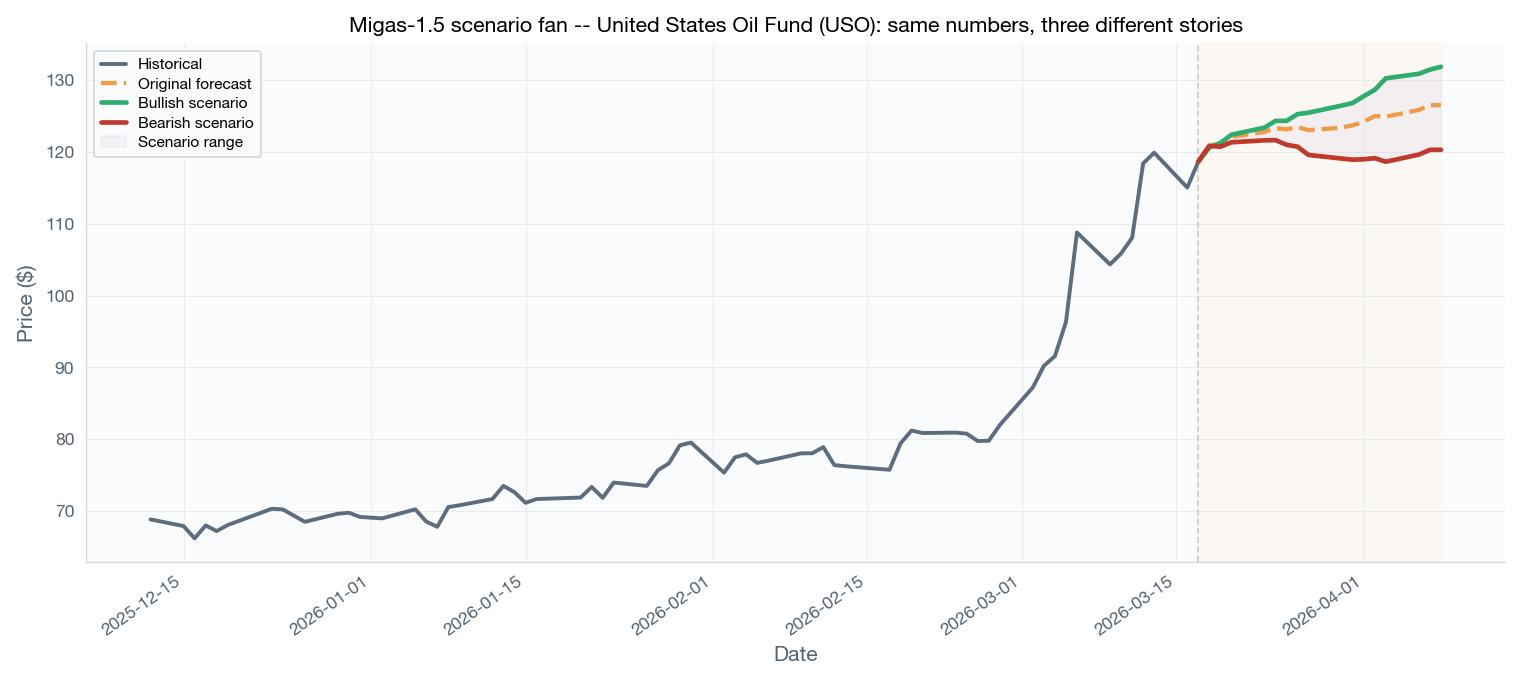

In [9]:
BULLISH_COLOR = "#2EAD6D"
BEARISH_COLOR = "#C0392B"

t_ctx = pd.to_datetime(raw["t"].values)
last_date = pd.to_datetime(raw["t"].iloc[-1])
t_pred = pd.bdate_range(start=last_date, periods=PRED_LEN + 1)
last_val = float(context_vals[-1])

fig, ax = plt.subplots(figsize=(11, 5))
_draw_forecast_region(
    ax, CONTEXT_LEN, PRED_LEN, boundary=t_pred[0], boundary_end=t_pred[-1]
)

ax.plot(
    t_ctx, context_vals, color=COLORS["historical"], lw=2.0,
    label="Historical", solid_capstyle="round",
)
ax.plot(
    t_pred, np.concatenate([[last_val], fc_original]),
    color=COLORS["Migas-1.5"], lw=2.2, ls="--", alpha=0.85,
    label="Original forecast", solid_capstyle="round",
)
ax.plot(
    t_pred, np.concatenate([[last_val], fc_bullish]),
    color=BULLISH_COLOR, lw=2.4, label="Bullish scenario",
    solid_capstyle="round",
)
ax.plot(
    t_pred, np.concatenate([[last_val], fc_bearish]),
    color=BEARISH_COLOR, lw=2.4, label="Bearish scenario",
    solid_capstyle="round",
)
ax.fill_between(
    t_pred,
    np.concatenate([[last_val], fc_bearish]),
    np.concatenate([[last_val], fc_bullish]),
    alpha=0.08, color="#9B8EC4", label="Scenario range",
)

format_date_axis(ax)
ax.set_xlabel("Date", color="#566573")
ax.set_ylabel("Price ($)", color="#566573")
ax.set_title(
    f"Migas-1.5 scenario fan -- {SERIES_NAME}: same numbers, three different stories",
    fontsize=11, fontweight=600,
)
ax.legend(fontsize=8, handlelength=1.6, labelspacing=0.35, borderpad=0.45)
fig.tight_layout(pad=1.2)
plt.show()

## What's next

The forecast genuinely shifts when the narrative changes, while the numerical
input stays identical. This confirms that Migas-1.5 integrates textual signals
into its predictions.

- **Try another asset** -- change `TICKER` at the top to any Yahoo Finance symbol
- **Generate fresh summaries** -- set `ANTHROPIC_API_KEY` in `.env` for Claude-powered summaries with web search
- **Batch evaluation** -- see [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb) for rolling-window evaluation
- **Counterfactual utilities** -- all tools used here are available via `migaseval.counterfactual_utils`